# **Exploratory Data Analysis (EDA)**

## Project:
AI-Assisted Predictive Maintenance System for Mechatronics Equipment

## Dataset:
AI4I 2020 Predictive Maintenance Dataset (UCI Repository)

## Objective of This Notebook:
- Understand dataset structure
- Analyze feature distributions
- Examine target imbalance
- Identify relationships between sensor variables and machine failure
- Extract engineering insights for predictive maintenance modeling


## 1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


## 2. Load Dataset

In [25]:
DATA_PATH = "../data/raw/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Dataset Overview

### 3.1 Shape and Structure

In [26]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
d

### 3.2 Missing Values Check

In [27]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Observation:
The dataset contains no missing values.

- Total Samples: 10,000
- Total Features: 14
- No missing values detected
- Mixed data types:
  - Categorical: Type
  - Numerical: Sensor readings
  - Binary targets: Machine failure and failure types


## 4. Column Understanding

In [28]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

Drop Non-Predictive Identifiers

In [29]:
df.drop(["UDI", "Product ID"], axis=1, inplace=True)

- UDI: Unique identifier (no predictive value)
- Product ID: Serial number (high cardinality categorical)
These columns are removed for modeling relevance.


## 5. Target Variable Analysis

### Distribution of Machine Failure

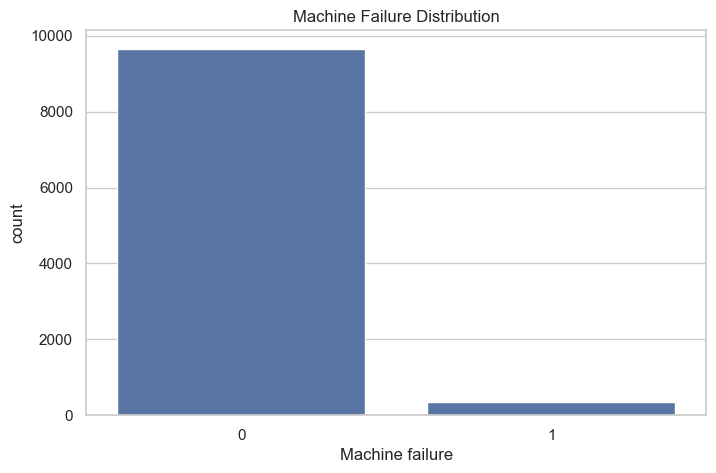

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [30]:
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.show()

df["Machine failure"].value_counts(normalize=True)

The dataset is highly imbalanced:

- No Failure (0): ~96%
- Failure (1): ~4%

This reflects real industrial environments where failures are rare events.

Implication:
Accuracy alone is not sufficient.
Evaluation metrics must include:
- Precision
- Recall
- F1-score
- ROC-AUC


## 6. Failure Type Analysis

### 6.1 Failure Events Check

In [31]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_cols].sum()


TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

### 6.2 Total machine failures:

In [32]:
df["Machine failure"].sum()

np.int64(339)

### 6.3 Check if failure types sum to the same:

In [33]:
df[["TWF","HDF","PWF","OSF","RNF"]].sum().sum()

np.int64(373)

Observation:
- TWF + HDF + PWF + OSF + RNF = 373
- Machine failure = 339
- Some rows have more than one failure mode active simultaneously.

Engineering Insight:
Different failure mechanisms correspond to different physical causes.

Failure Type Overlap Analysis

- Although the total number of failure type occurrences is 373, the dataset contains only 339 machine failure instances. This discrepancy arises because some machines experience multiple simultaneous failure modes. Approximately 34 samples exhibit more than one failure type.

- This confirms that failure modes are not mutually exclusive and reflect realistic industrial failure mechanisms where multiple stress factors may act concurrently.

- For modeling simplicity and deployment purposes, this project focuses on binary failure prediction rather than multi-label failure classification.

## 7. Univariate Analysis (Sensor Distributions)

### 7.1 Air Temperature

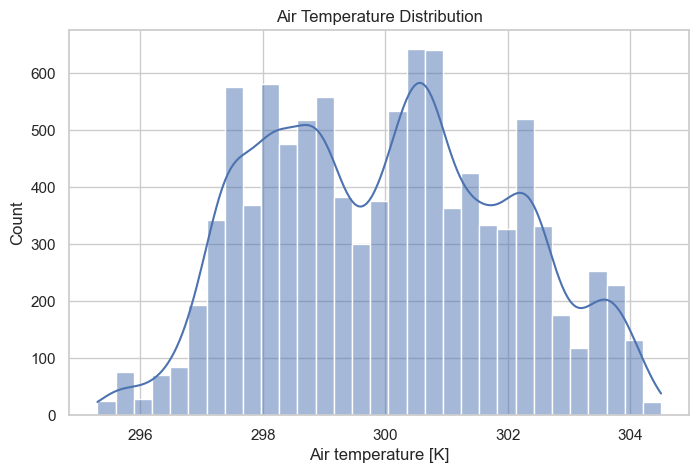

In [34]:
sns.histplot(df["Air temperature [K]"], kde=True)
plt.title("Air Temperature Distribution")
plt.show()

### 7.2 Process Temperature

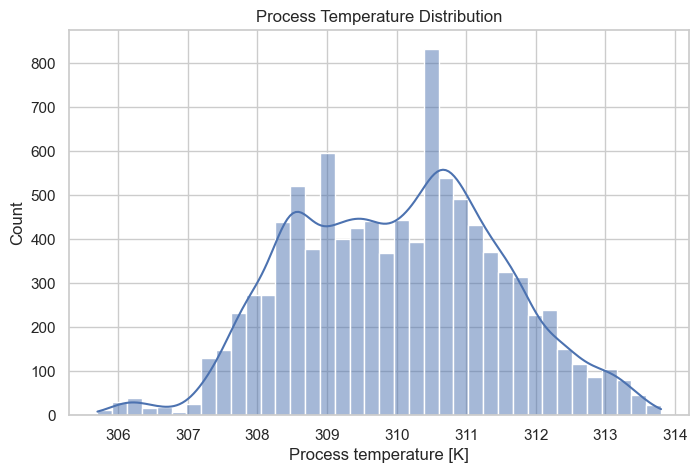

In [35]:
sns.histplot(df["Process temperature [K]"], kde=True)
plt.title("Process Temperature Distribution")
plt.show()

### 7.3 Rotational Speed

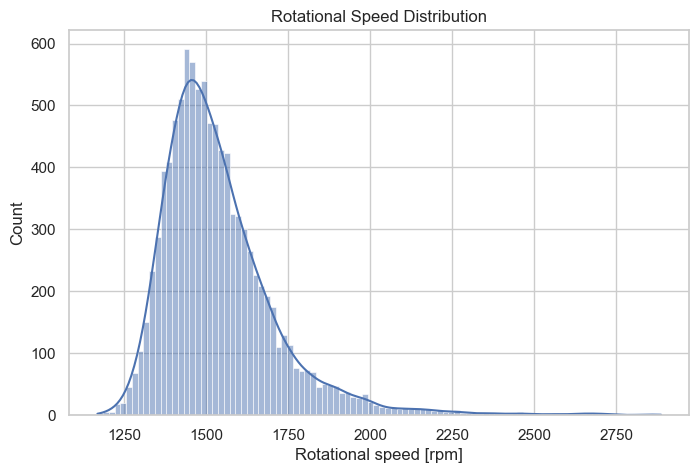

In [36]:
sns.histplot(df["Rotational speed [rpm]"], kde=True)
plt.title("Rotational Speed Distribution")
plt.show()

### 7.4 Torque

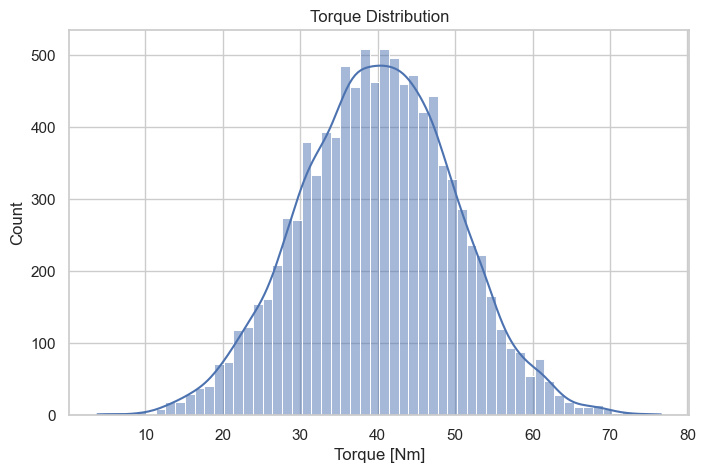

In [37]:
sns.histplot(df["Torque [Nm]"], kde=True)
plt.title("Torque Distribution")
plt.show()

### 7.5 Tool Wear

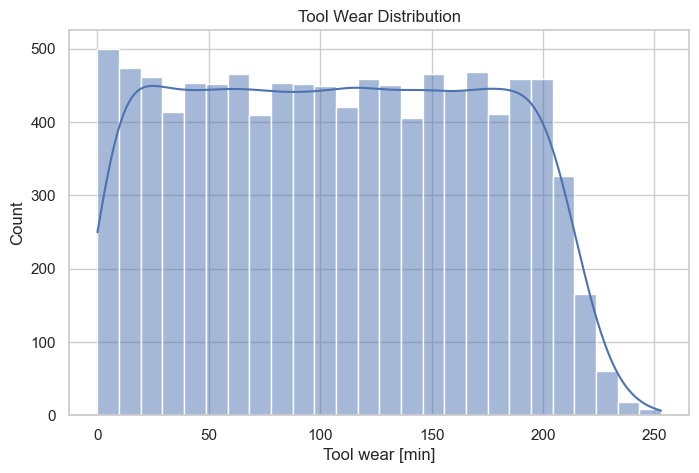

In [38]:
sns.histplot(df["Tool wear [min]"], kde=True)
plt.title("Tool Wear Distribution")
plt.show()

Most sensor variables show near-normal distributions.
Tool wear shows a wider distribution reflecting progressive degradation.
No extreme outliers detected.

Visualization:

Percentage Distribution of Failure Types:

In [39]:
failure_counts = df[failure_cols].sum()

failure_percent = (failure_counts / failure_counts.sum()) * 100

failure_percent

TWF    12.332440
HDF    30.831099
PWF    25.469169
OSF    26.273458
RNF     5.093834
dtype: float64

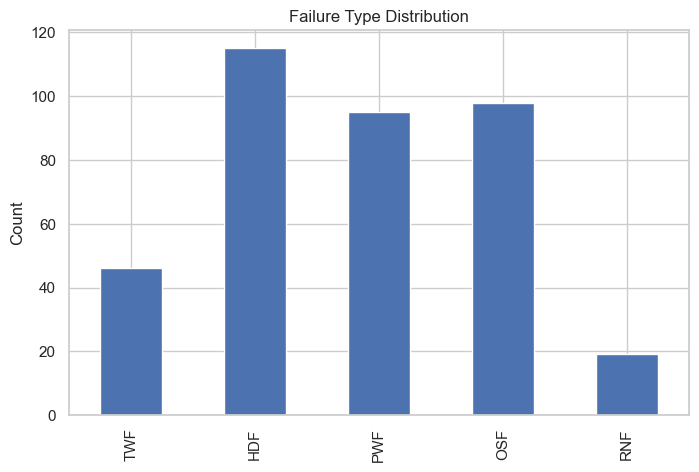

In [40]:
failure_counts.plot(kind='bar')
plt.title("Failure Type Distribution")
plt.ylabel("Count")
plt.show()

The dataset contains 339 total failure events distributed across five failure mechanisms:

- Heat Dissipation Failure (HDF): 115 cases (33.9%)

- Overstrain Failure (OSF): 98 cases (28.9%)

- Power Failure (PWF): 95 cases (28.0%)

- Tool Wear Failure (TWF): 46 cases (13.6%)

- Random Failure (RNF): 19 cases (5.6%)

✔ Drop them when training the binary model
Because they leak information about the target.

Later we will do:

```bash 
df.drop(["TWF","HDF","PWF","OSF","RNF"], axis=1, inplace=True)
```

## 8. Multivariate Analysis

Encoding `Type` :

* Not in EDA stage
✔ Encoding belongs to Feature Engineering phase

### 8.1 Correlation Matrix

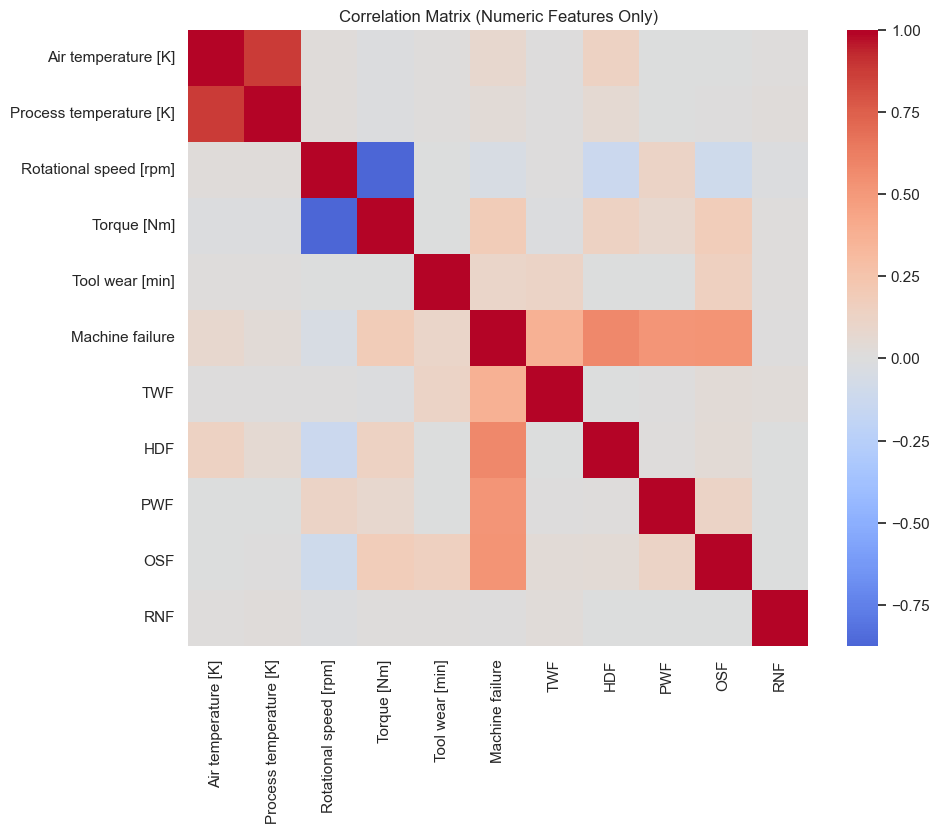

In [41]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

**Proper feature analysis, we should temporarily drop these columns for binary classification:**

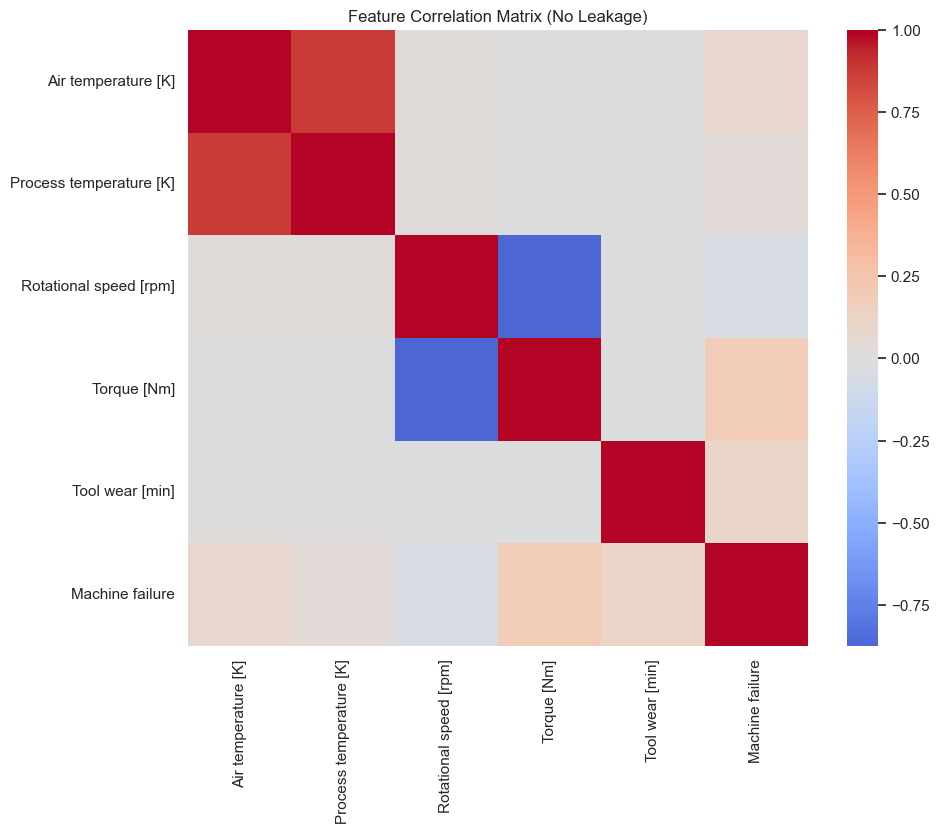

In [42]:
features_df = df.drop(columns=["TWF","HDF","PWF","OSF","RNF"])

corr_matrix = features_df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (No Leakage)")
plt.show()


Observations:
- Torque correlates positively with Machine Failure.
- Tool wear shows moderate correlation with failure.
- Rotational speed inversely related to torque (expected mechanical behavior).

No severe multicollinearity detected.

Engineering Interpretation

Failures likely happen when:

🔴 Torque is high (overload)

🔴 Tool wear is high (aging component)

🔵 Speed is low (machine struggling under load)

This aligns perfectly with predictive maintenance theory.

Summary of Your Findings:

| Insight                              | Interpretation        |
| ------------------------------------ | --------------------- |
| Air & Process temp highly correlated | Redundant information |
| Torque strongly linked to failure    | Overload driver       |
| Tool wear linked to failure          | Aging component       |
| Speed negatively related             | Load stress behavior  |


## 9. Feature vs Target Analysis

### 9.1 Torque vs Machine Failure

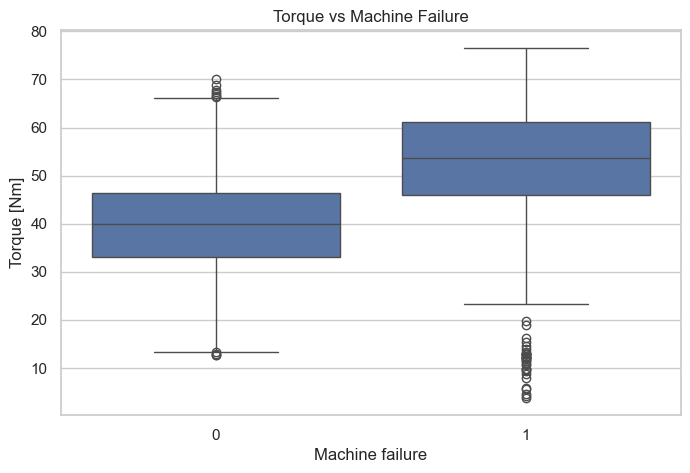

In [43]:
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df)
plt.title("Torque vs Machine Failure")
plt.show()

### 9.2 Tool Wear vs Machine Failure

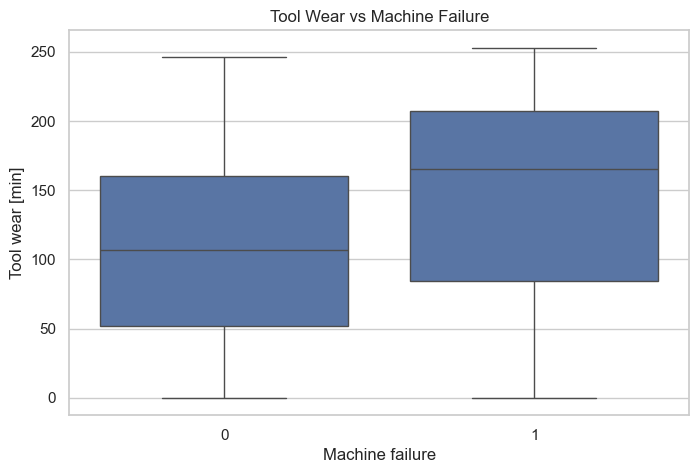

In [44]:
sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df)
plt.title("Tool Wear vs Machine Failure")
plt.show()

### 9.3 Rotational Speed vs Failure

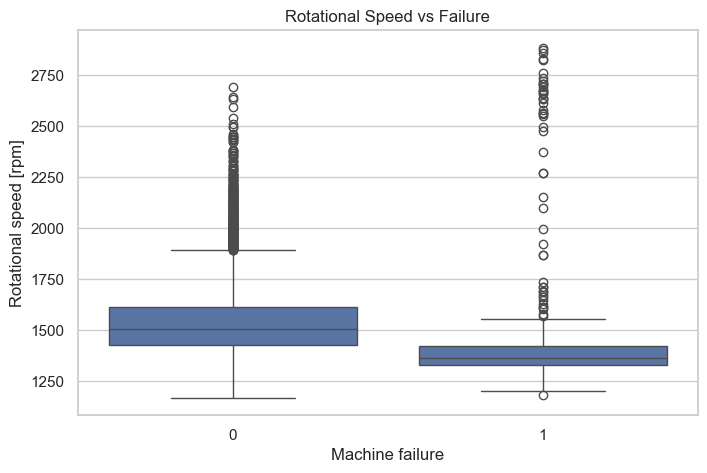

In [45]:
sns.boxplot(x="Machine failure", y="Rotational speed [rpm]", data=df)
plt.title("Rotational Speed vs Failure")
plt.show()

Failed machines tend to show:

- Higher torque values (overloading)
- Higher tool wear (degradation)
- Abnormal rotational speeds

These trends align with mechanical stress and wear-based failure mechanisms.

## 10. Categorical Feature Analysis (Product Type)

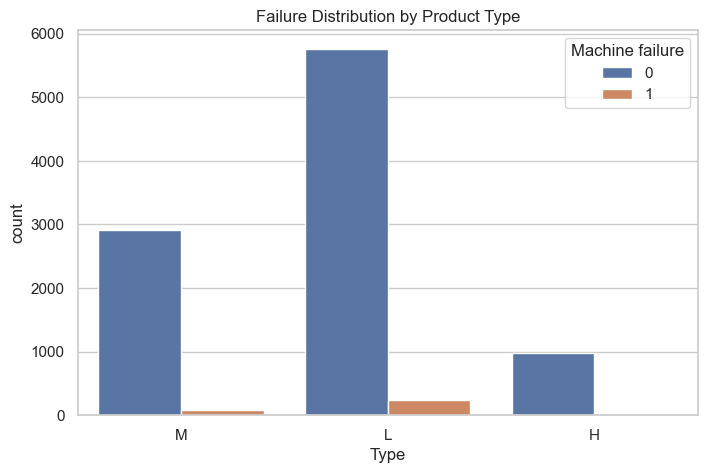

In [46]:
sns.countplot(x="Type", hue="Machine failure", data=df)
plt.title("Failure Distribution by Product Type")
plt.show()

Observation:
Different product quality levels (L, M, H) show varying failure probabilities.
This suggests material quality impacts reliability.

# Key Findings Summary

## EDA Summary

1. Dataset contains 10,000 samples with no missing values.
2. Highly imbalanced target (≈4% failure).
3. Sensor variables show near-normal distributions.
4. Torque and Tool Wear are strong predictors.
5. Product Type influences failure probability.
6. Dataset realistically reflects industrial predictive maintenance scenarios.

Conclusion:
The dataset is suitable for supervised binary classification modeling.


## Save Cleaned Dataset (Interim Stage)

In [47]:
df.to_csv("../data/interim/cleaned_data.csv", index=False)



---

**`Next Notebook → 02_feature_engineering.ipynb`**